# Model rating analysis notebook

This notebook implements the workflow requested for four evaluator/model files.

Key design choices:
- The five columns of the excel file are ordinal Likert-style metrics:
  1. Accuracy of final diagnosis
  2. Clinical reasoning quality
  3. Strength of justification
  4. Clinical safety
  5. Clarity and medical language
- Agreement is evaluated using **quadratic weighted Cohen's kappa** per metric and globally.
- ICC is also computed as a secondary reliability estimate.
- Averaging across users is performed only if **global agreement is ≥ 0.75 for both models**.
- Model comparisons use paired Wilcoxon signed-rank tests, with FDR correction and matched-pairs rank-biserial effect sizes.

## Imports and configuration

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon
# import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path("./../results/OpenEvidence-independent")

FILES = {
    ("llama3.1-8B-Instruct", "user1"): DATA_DIR / "llama3.1-8B-Instruct_user1.xlsx",
    ("llama3.1-8B-Instruct", "user2"): DATA_DIR / "llama3.1-8B-Instruct_user2.xlsx",
    ("huatuogpt-o1-8B", "user1"): DATA_DIR / "huatuogpt-o1-8B_user1.xlsx",
    ("huatuogpt-o1-8B", "user2"): DATA_DIR / "huatuogpt-o1-8B_user2.xlsx",
}

METRICS = [
    "Accuracy of final diagnosis",
    "Clinical reasoning quality",
    "Strength of justification",
    "Clinical safety",
    "Clarity and medical language",
]

AGREEMENT_THRESHOLD = 0.75
RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)


## Load the four rating files

In [2]:
def read_rating_file(path, model, evaluator):
    df = pd.read_excel(path, header=None)
    if df.shape[1] < 6:
        raise ValueError(f"{path.name} has {df.shape[1]} columns. Expected at least 6 columns.")
    df = df.iloc[:, :6].copy()
    df.columns = ["case_id"] + METRICS
    df["model"] = model
    df["evaluator"] = evaluator
    df["source_file"] = path.name

    for col in ["case_id"] + METRICS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["case_id"] = df["case_id"].astype("Int64")
    return df

ratings = pd.concat(
    [read_rating_file(path, model, evaluator) for (model, evaluator), path in FILES.items()],
    ignore_index=True,
)

ratings = ratings[["model", "evaluator", "case_id"] + METRICS + ["source_file"]]

print("Loaded data shape:", ratings.shape)
display(ratings.head())
display(ratings.groupby(["model", "evaluator"]).size().rename("n_rows").reset_index())

Loaded data shape: (364, 9)


,model,evaluator,case_id,Accuracy of final diagnosis,Clinical reasoning quality,Strength of justification,Clinical safety,Clarity and medical language,source_file
0,llama3.1-8B-Instruct,user1,1,2,2,2,2,3,llama3.1-8B-Instruct_user1.xlsx
1,llama3.1-8B-Instruct,user1,2,1,2,2,1,3,llama3.1-8B-Instruct_user1.xlsx
2,llama3.1-8B-Instruct,user1,5,1,2,2,2,4,llama3.1-8B-Instruct_user1.xlsx
3,llama3.1-8B-Instruct,user1,7,1,2,2,2,4,llama3.1-8B-Instruct_user1.xlsx
4,llama3.1-8B-Instruct,user1,8,1,2,2,2,4,llama3.1-8B-Instruct_user1.xlsx


,model,evaluator,n_rows
0,huatuogpt-o1-8B,user1,91
1,huatuogpt-o1-8B,user2,91
2,llama3.1-8B-Instruct,user1,91
3,llama3.1-8B-Instruct,user2,91


In [3]:
# is one model better than another?

## Descriptive statistics for the four files separately

In [4]:
def descriptive_stats_by_file(df):
    long = df.melt(
        id_vars=["model", "evaluator", "case_id", "source_file"],
        value_vars=METRICS,
        var_name="metric",
        value_name="score",
    )
    desc = (
        long
        .groupby(["source_file", "model", "evaluator", "metric"])["score"]
        .agg(
            n="count",
            missing=lambda x: x.isna().sum(),
            mean="mean",
            sd="std",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            minimum="min",
            maximum="max",
        )
        .reset_index()
    )
    return desc

desc_by_file = descriptive_stats_by_file(ratings)
display(desc_by_file)

,source_file,model,evaluator,metric,n,missing,mean,sd,median,q1,q3,minimum,maximum
0,huatuogpt-o1-8B_user1.xlsx,huatuogpt-o1-8B,user1,Accuracy of final diagnosis,91,0,2.351648,1.702114,1.0,1.0,4.0,1,5
1,huatuogpt-o1-8B_user1.xlsx,huatuogpt-o1-8B,user1,Clarity and medical language,91,0,2.857143,0.676123,3.0,2.0,3.0,2,4
2,huatuogpt-o1-8B_user1.xlsx,huatuogpt-o1-8B,user1,Clinical reasoning quality,91,0,2.153846,0.713724,2.0,2.0,3.0,1,4
3,huatuogpt-o1-8B_user1.xlsx,huatuogpt-o1-8B,user1,Clinical safety,91,0,2.406593,1.154489,2.0,1.0,3.0,1,5
4,huatuogpt-o1-8B_user1.xlsx,huatuogpt-o1-8B,user1,Strength of justification,91,0,1.978022,0.774281,2.0,1.0,2.0,1,4
5,huatuogpt-o1-8B_user2.xlsx,huatuogpt-o1-8B,user2,Accuracy of final diagnosis,91,0,2.340659,1.634488,1.0,1.0,4.0,1,5
6,huatuogpt-o1-8B_user2.xlsx,huatuogpt-o1-8B,user2,Clarity and medical language,91,0,2.846154,0.648470,3.0,2.0,3.0,1,5
7,huatuogpt-o1-8B_user2.xlsx,huatuogpt-o1-8B,user2,Clinical reasoning quality,91,0,2.263736,0.712354,2.0,2.0,3.0,1,4
8,huatuogpt-o1-8B_user2.xlsx,huatuogpt-o1-8B,user2,Clinical safety,91,0,2.362637,1.100671,2.0,1.0,3.0,1,5
9,huatuogpt-o1-8B_user2.xlsx,huatuogpt-o1-8B,user2,Strength of justification,91,0,1.934066,0.696056,2.0,1.0,2.0,1,3


Agreement between user 1 and user 2

Agreement is computed per model and per metric using exact agreement, mean absolute difference, weighted kappa, and ICC. Global agreement pools the five metric ratings within each model.

In [5]:
def icc_two_way_random_absolute(data):
    # ICC(2,1) and ICC(2,k), two-way random-effects (both cases and evaluators are randomly samples) absolute agreement.
    # Rows = targets/cases, columns = raters/evaluators.
    data = np.asarray(data, dtype=float)
    mask = ~np.isnan(data).any(axis=1)
    data = data[mask]

    n, k = data.shape
    if n < 2 or k < 2:
        return {"icc2_1": np.nan, "icc2_k": np.nan, "n": n}

    mean_targets = np.mean(data, axis=1)  # mean score per case across evaluators
    mean_raters = np.mean(data, axis=0)  # mean score per evaluator across cases
    grand_mean = np.mean(data)  # overall mean across everything

    ss_targets = k * np.sum((mean_targets - grand_mean) ** 2)  # sum of squares - how much cases differ from each other
    ss_raters = n * np.sum((mean_raters - grand_mean) ** 2)  # how much evaluators systematically differ
    ss_error = np.sum((data - mean_targets[:, None] - mean_raters[None, :] + grand_mean) ** 2) # residual disagreement

    ms_targets = ss_targets / (n - 1)  # variance between cases
    ms_raters = ss_raters / (k - 1)  # variance between evaluators
    ms_error = ss_error / ((n - 1) * (k - 1))  # unexplained disagreement

    icc2_1 = (ms_targets - ms_error) / (
        ms_targets + (k - 1) * ms_error + (k * (ms_raters - ms_error) / n)  # single evaluator score
    )
    # if we randomly take an evaluator - how reliable is their score
    icc2_k = (ms_targets - ms_error) / (
        ms_targets + ((ms_raters - ms_error) / n)
    )  # reliability of average across evaluators

    return {"icc2_1": icc2_1, "icc2_k": icc2_k, "n": n}


def agreement_for_model_metric(df, model, metric):
    # agreement per single model and single metric
    wide = (
        df[df["model"] == model]
        .pivot_table(index="case_id", columns="evaluator", values=metric, aggfunc="first")
        .dropna()
    ) 
    if not {"user1", "user2"}.issubset(wide.columns):
        return None

    y1 = wide["user1"].astype(int) # per user
    y2 = wide["user2"].astype(int)

    exact_agreement = (y1 == y2).mean() # portion of cases with agreement
    abs_diff = (y1 - y2).abs()

    icc = icc_two_way_random_absolute(wide[["user1", "user2"]].values)

    return {
        "model": model,
        "metric": metric,
        "n": len(wide),
        "exact_agreement": exact_agreement,
        "mean_abs_difference": abs_diff.mean(),
        "quadratic_weighted_kappa": cohen_kappa_score(y1, y2, weights="quadratic"), # penalizing large disagreements
        "linear_weighted_kappa": cohen_kappa_score(y1, y2, weights="linear"),
        "icc2_1_single_rater": icc["icc2_1"],
        "icc2_k_average_raters": icc["icc2_k"],
    }


agreement_rows = []
for model in ratings["model"].unique():
    for metric in METRICS:
        agreement_rows.append(agreement_for_model_metric(ratings, model, metric))

agreement_by_metric = pd.DataFrame([r for r in agreement_rows if r is not None])
display(agreement_by_metric)


def global_agreement_for_model(df, model):
    pairs = []
    for metric in METRICS:
        wide = (
            df[df["model"] == model]
            .pivot_table(index="case_id", columns="evaluator", values=metric, aggfunc="first")
            .dropna()
        )
        tmp = pd.DataFrame({
            "case_id": wide.index,
            "metric": metric,
            "user1": wide["user1"].values,
            "user2": wide["user2"].values,
        })
        pairs.append(tmp)

    pooled = pd.concat(pairs, ignore_index=True).dropna()
    y1 = pooled["user1"].astype(int)
    y2 = pooled["user2"].astype(int)

    icc = icc_two_way_random_absolute(pooled[["user1", "user2"]].values)

    return {
        "model": model,
        "n_pooled_ratings": len(pooled),
        "exact_agreement": (y1 == y2).mean(),
        "mean_abs_difference": (y1 - y2).abs().mean(),
        "quadratic_weighted_kappa": cohen_kappa_score(y1, y2, weights="quadratic"),
        "linear_weighted_kappa": cohen_kappa_score(y1, y2, weights="linear"),
        "icc2_1_single_rater": icc["icc2_1"],
        "icc2_k_average_raters": icc["icc2_k"],
    }

global_agreement = pd.DataFrame([
    global_agreement_for_model(ratings, model)
    for model in ratings["model"].unique()
])

global_agreement["meets_averaging_threshold"] = global_agreement["quadratic_weighted_kappa"] >= AGREEMENT_THRESHOLD

display(global_agreement)

CAN_AVERAGE = bool(global_agreement["meets_averaging_threshold"].all())
print(f"Agreement threshold for averaging: {AGREEMENT_THRESHOLD}")
print(f"Average across evaluators for main analysis? {CAN_AVERAGE}")


,model,metric,n,exact_agreement,mean_abs_difference,quadratic_weighted_kappa,linear_weighted_kappa,icc2_1_single_rater,icc2_k_average_raters
0,llama3.1-8B-Instruct,Accuracy of final diagnosis,91,0.835165,0.285714,0.891637,0.833075,0.892700,0.943308
1,llama3.1-8B-Instruct,Clinical reasoning quality,91,0.824176,0.186813,0.852512,0.789438,0.853896,0.921191
2,llama3.1-8B-Instruct,Strength of justification,91,0.769231,0.241758,0.774566,0.693897,0.758281,0.862525
3,llama3.1-8B-Instruct,Clinical safety,91,0.835165,0.175824,0.918806,0.854371,0.919627,0.958131
4,llama3.1-8B-Instruct,Clarity and medical language,91,0.725275,0.274725,0.742210,0.637219,0.744318,0.853420
5,huatuogpt-o1-8B,Accuracy of final diagnosis,91,0.813187,0.208791,0.950119,0.878248,0.950641,0.974696
6,huatuogpt-o1-8B,Clinical reasoning quality,91,0.802198,0.197802,0.805648,0.727997,0.807372,0.893421
7,huatuogpt-o1-8B,Strength of justification,91,0.747253,0.263736,0.733978,0.656712,0.736130,0.848012
8,huatuogpt-o1-8B,Clinical safety,91,0.747253,0.263736,0.886545,0.788002,0.887651,0.940482
9,huatuogpt-o1-8B,Clarity and medical language,91,0.582418,0.450549,0.405063,0.327142,0.407729,0.579272


,model,n_pooled_ratings,exact_agreement,mean_abs_difference,quadratic_weighted_kappa,linear_weighted_kappa,icc2_1_single_rater,icc2_k_average_raters,meets_averaging_threshold
0,llama3.1-8B-Instruct,455,0.797802,0.232967,0.881314,0.814590,0.881543,0.937043,True
1,huatuogpt-o1-8B,455,0.738462,0.276923,0.868137,0.766332,0.868389,0.929559,True


Agreement threshold for averaging: 0.75
Average across evaluators for main analysis? True


## Show all values

In [6]:
wide_values = ratings.pivot_table(
    index="case_id",
    columns=["model", "evaluator"],
    values=METRICS,
    aggfunc="first"
)

wide_values = wide_values.sort_index(axis=1)
display(wide_values)

long_values = ratings.melt(
    id_vars=["model", "evaluator", "case_id", "source_file"],
    value_vars=METRICS,
    var_name="metric",
    value_name="score",
)
display(long_values.head(20))

Accuracy of final diagnosis                                  Clarity and medical language                                   \
model                 huatuogpt-o1-8B       llama3.1-8B-Instruct                    huatuogpt-o1-8B       llama3.1-8B-Instruct         
evaluator                       user1 user2                user1 user2                        user1 user2                user1 user2   
case_id                                                                                                                                
1                                   5     5                    2     5                            2     4                    3     3   
2                                   1     1                    1     1                            3     3                    3     4   
5                                   5     5                    1     1                            3     2                    4     4   
7                                   1     1                    1     1                            3     2                    4     4   
8                                   1     1                    1     1                            4     3                    4     4   
...                               ...   ...                  ...   ...                          ...   ...                  ...   ...   
95                                  1     1                    5     5                            3     3                    3     4   
96                                  1     1                    1     1                            2     3                    3     3   
97                                  1     1                    1     1                            3     3                    2     2   
98                                  1     1                    1     1                            3     3                    3     3   
99                                  4     5                    5     5                            2     3                    3     3   

          Clinical reasoning quality                                  Clinical safety                                  Strength of justification        \
model                huatuogpt-o1-8B       llama3.1-8B-Instruct       huatuogpt-o1-8B       llama3.1-8B-Instruct                 huatuogpt-o1-8B         
evaluator                      user1 user2                user1 user2           user1 user2                user1 user2                     user1 user2   
case_id                                                                                                                                                  
1                                  2     3                    2     2               3     3                    2     2                         3     3   
2                                  2     2                    2     2               1     2                    1     2                         2     1   
5                                  2     3                    2     2               4     4                    2     2                         3     3   
7                                  2     2                    2     2               2     2                    2     2                         2     1   
8                                  2     2                    2     2               2     2                    2     2                         2     2   
...                              ...   ...                  ...   ...             ...   ...                  ...   ...                       ...   ...   
95                                 2     2                    3     3               1     1                    4     4                         2     1   
96                                 1     1                    2     2               1     1                    2     2                         1     1   
97                                 2     2                    1     1               2     2                    2     2   

,model,evaluator,case_id,source_file,metric,score
0,llama3.1-8B-Instruct,user1,1,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,2
1,llama3.1-8B-Instruct,user1,2,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
2,llama3.1-8B-Instruct,user1,5,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
3,llama3.1-8B-Instruct,user1,7,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
4,llama3.1-8B-Instruct,user1,8,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
5,llama3.1-8B-Instruct,user1,9,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
6,llama3.1-8B-Instruct,user1,10,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,5
7,llama3.1-8B-Instruct,user1,11,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
8,llama3.1-8B-Instruct,user1,12,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,1
9,llama3.1-8B-Instruct,user1,13,llama3.1-8B-Instruct_user1.xlsx,Accuracy of final diagnosis,4


## Average across users given global agreement $\geq$ 0.75

In [7]:
def make_averaged_dataset(df):
    avg = (
        df
        .groupby(["model", "case_id"], as_index=False)[METRICS]
        .mean()
    )
    avg["evaluator"] = "average_user1_user2"
    return avg

if CAN_AVERAGE:
    analysis_df = make_averaged_dataset(ratings)
    analysis_label = "Averaged across users because global weighted kappa >= 0.75 for both models."
else:
    analysis_df = ratings.copy()
    analysis_label = "Not averaged because at least one model did not reach global weighted kappa >= 0.75."

print(analysis_df.shape)
print(analysis_label)
display(analysis_df.head())

analysis_long = analysis_df.melt(
    id_vars=["model", "evaluator", "case_id"],
    value_vars=METRICS,
    var_name="metric",
    value_name="score",
)

desc_analysis = (
    analysis_long
    .groupby(["model", "evaluator", "metric"])["score"]
    .agg(
        n="count",
        mean="mean",
        sd="std",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

display(desc_analysis)

(182, 8)
Averaged across users because global weighted kappa >= 0.75 for both models.


,model,case_id,Accuracy of final diagnosis,Clinical reasoning quality,Strength of justification,Clinical safety,Clarity and medical language,evaluator
0,huatuogpt-o1-8B,1,5.0,2.5,3.0,3.0,3.0,average_user1_user2
1,huatuogpt-o1-8B,2,1.0,2.0,1.5,1.5,3.0,average_user1_user2
2,huatuogpt-o1-8B,5,5.0,2.5,3.0,4.0,2.5,average_user1_user2
3,huatuogpt-o1-8B,7,1.0,2.0,1.5,2.0,2.5,average_user1_user2
4,huatuogpt-o1-8B,8,1.0,2.0,2.0,2.0,3.5,average_user1_user2


,model,evaluator,metric,n,mean,sd,median,q1,q3,minimum,maximum
0,huatuogpt-o1-8B,average_user1_user2,Accuracy of final diagnosis,91,2.346154,1.647713,1.0,1.0,4.00,1.0,5.0
1,huatuogpt-o1-8B,average_user1_user2,Clarity and medical language,91,2.851648,0.555250,3.0,2.5,3.00,1.5,4.0
2,huatuogpt-o1-8B,average_user1_user2,Clinical reasoning quality,91,2.208791,0.679321,2.0,2.0,2.50,1.0,4.0
3,huatuogpt-o1-8B,average_user1_user2,Clinical safety,91,2.384615,1.095640,2.0,1.5,3.00,1.0,5.0
4,huatuogpt-o1-8B,average_user1_user2,Strength of justification,91,1.956044,0.685761,2.0,1.5,2.50,1.0,3.5
5,llama3.1-8B-Instruct,average_user1_user2,Accuracy of final diagnosis,91,2.263736,1.705124,1.0,1.0,4.25,1.0,5.0
6,llama3.1-8B-Instruct,average_user1_user2,Clarity and medical language,91,2.928571,0.673182,3.0,2.5,3.25,1.0,4.5
7,llama3.1-8B-Instruct,average_user1_user2,Clinical reasoning quality,91,1.950549,0.813275,2.0,1.0,2.00,1.0,4.0
8,llama3.1-8B-Instruct,average_user1_user2,Clinical safety,91,2.263736,1.086126,2.0,1.5,3.00,1.0,5.0
9,llama3.1-8B-Instruct,average_user1_user2,Strength of justification,91,1.824176,0.692715,2.0,1.0,2.00,1.0,4.0


## Paired tests, effect sizes, and multiple-testing correction

The paired comparison is HuatuoGPT-o1-8B minus Llama3.1-8B-Instruct. Positive differences/effect sizes favor Huatuo; negative values favor Llama.

In [8]:
MODEL_A = "llama3.1-8B-Instruct"
MODEL_B = "huatuogpt-o1-8B"

def rank_biserial_effect_size_paired(x, y):
    diff = y - x  # different output between two models
    diff = diff[~np.isnan(diff)]  # remove missing difference
    diff = diff[diff != 0]  # remove cases when equal zero

    if len(diff) == 0:
        return np.nan

    ranks = stats.rankdata(np.abs(diff))  # take absolute, rank from smallest to largest
    w_pos = ranks[diff > 0].sum()  # assigns depending on positive or negative contribution
    w_neg = ranks[diff < 0].sum()
    total = len(diff) * (len(diff) + 1) / 2  # sum of all ranks from 1 to N
    return (w_pos - w_neg) / total  # if +1 all pairs have y>x, if -1, all pairs have x>y, 0 no difference


def bootstrap_median_diff_ci(x, y, n_boot=1000, alpha=0.05, seed=123):
    rng = np.random.default_rng(seed)
    valid = ~(np.isnan(x) | np.isnan(y))
    x = np.asarray(x)[valid]
    y = np.asarray(y)[valid]
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs.append(np.median(y[idx] - x[idx]))

    lower = np.quantile(diffs, alpha / 2)
    upper = np.quantile(diffs, 1 - alpha / 2)
    return lower, upper


def paired_tests(df):
    rows = []

    for evaluator in sorted(df["evaluator"].dropna().unique()):
        sub = df[df["evaluator"] == evaluator]

        for metric in METRICS:
            wide = sub.pivot_table(index="case_id", columns="model", values=metric, aggfunc="first")
            wide = wide[[MODEL_A, MODEL_B]].dropna()

            x = wide[MODEL_A].astype(float).values
            y = wide[MODEL_B].astype(float).values
            diff = y - x

            if np.all(diff == 0):
                statistic, p_value = 0.0, 1.0
            else:
                statistic, p_value = stats.wilcoxon(y, x, zero_method="wilcox", alternative="two-sided")

            ci_low, ci_high = bootstrap_median_diff_ci(x, y, seed=RANDOM_SEED)

            rows.append({
                "evaluator": evaluator,
                "metric": metric,
                "n_pairs": len(wide),
                "median_llama": np.median(x),
                "median_huatuo": np.median(y),
                "median_difference_huatuo_minus_llama": np.median(diff),
                "median_difference_95ci_low": ci_low,
                "median_difference_95ci_high": ci_high,
                "wilcoxon_statistic": statistic,
                "p_value_raw": p_value,
                "rank_biserial_effect_size": rank_biserial_effect_size_paired(x, y),
                "mean_difference_huatuo_minus_llama": np.mean(diff),
            })

    results = pd.DataFrame(rows)

    reject, p_adj, _, _ = multipletests(results["p_value_raw"], method="fdr_bh")
    results["p_value_fdr_bh"] = p_adj
    results["significant_fdr_0.05"] = reject

    return results

comparison_results = paired_tests(analysis_df)
display(comparison_results)

,evaluator,metric,n_pairs,median_llama,median_huatuo,median_difference_huatuo_minus_llama,median_difference_95ci_low,median_difference_95ci_high,wilcoxon_statistic,p_value_raw,rank_biserial_effect_size,mean_difference_huatuo_minus_llama,p_value_fdr_bh,significant_fdr_0.05
0,average_user1_user2,Accuracy of final diagnosis,91,1.0,1.0,0.0,0.0,0.0,487.0,0.412288,0.136525,0.082418,0.436659,False
1,average_user1_user2,Clinical reasoning quality,91,2.0,2.0,0.0,0.0,0.5,422.5,0.002992,0.451299,0.258242,0.014960,True
2,average_user1_user2,Strength of justification,91,2.0,2.0,0.0,0.0,0.0,540.5,0.048148,0.298052,0.131868,0.120369,False
3,average_user1_user2,Clinical safety,91,2.0,2.0,0.0,0.0,0.0,480.5,0.123454,0.246275,0.120879,0.205756,False
4,average_user1_user2,Clarity and medical language,91,3.0,3.0,0.0,-0.5,0.0,1145.5,0.436659,-0.103678,-0.076923,0.436659,False


## Visualizations

This section generates boxplots, paired line plots, agreement heatmap, median/IQR summaries, FDR-adjusted p-value plots, and effect-size plots.

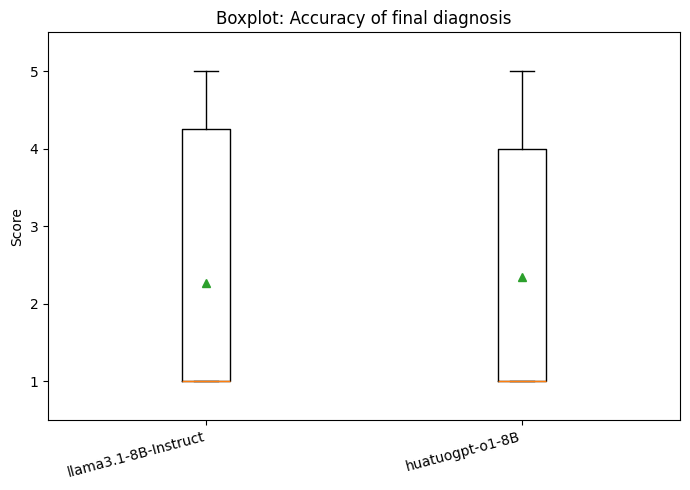

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/boxplot_Accuracy_of_final_diagnosis.png


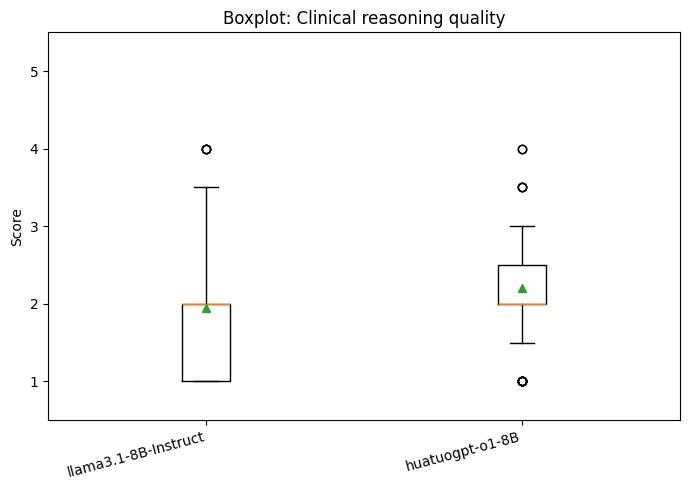

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/boxplot_Clinical_reasoning_quality.png


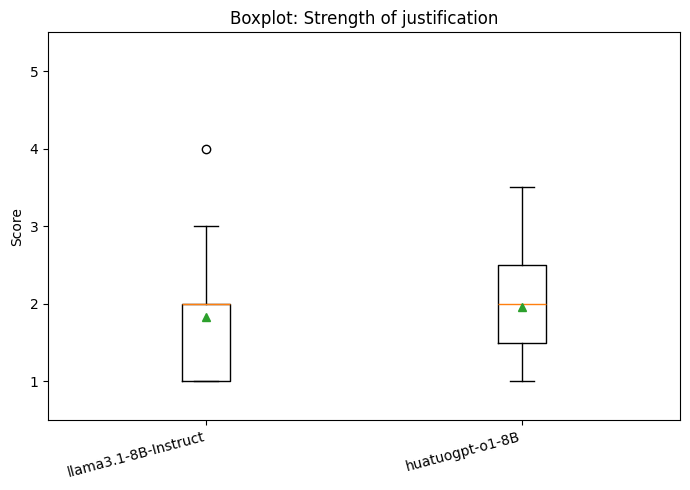

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/boxplot_Strength_of_justification.png


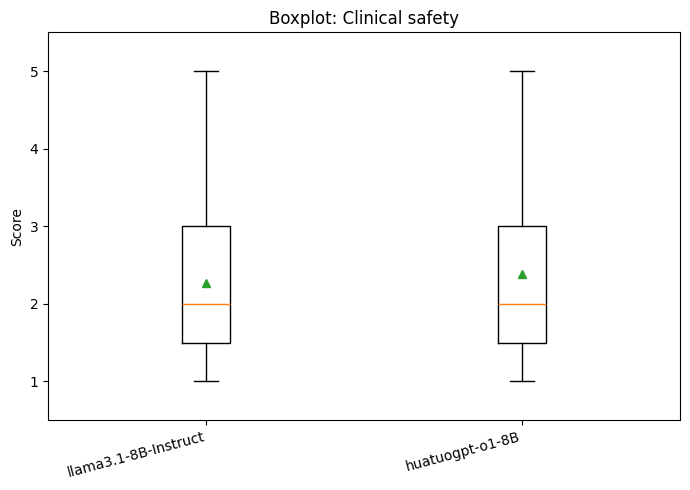

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/boxplot_Clinical_safety.png


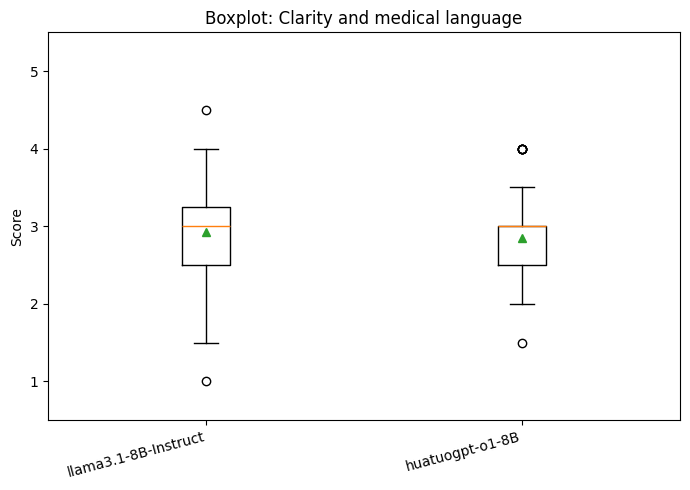

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/boxplot_Clarity_and_medical_language.png


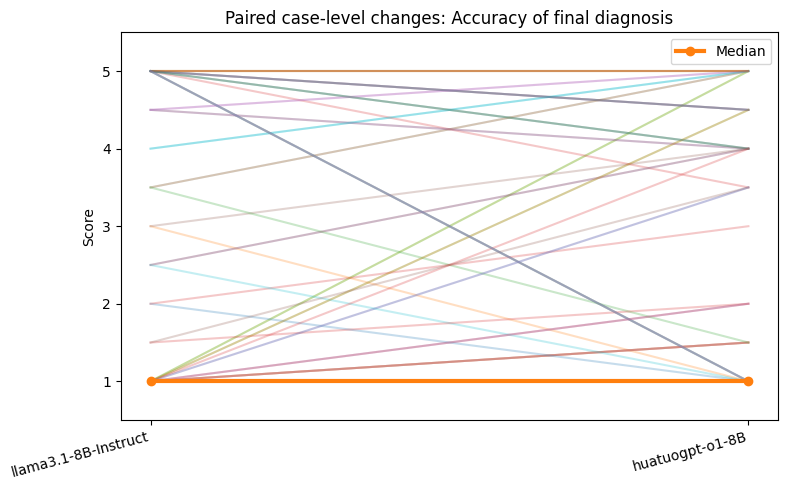

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/paired_lines_Accuracy_of_final_diagnosis.png


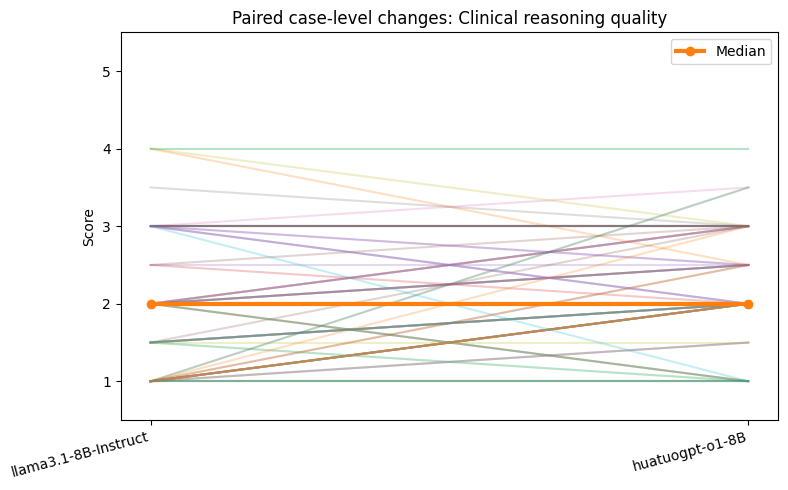

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/paired_lines_Clinical_reasoning_quality.png


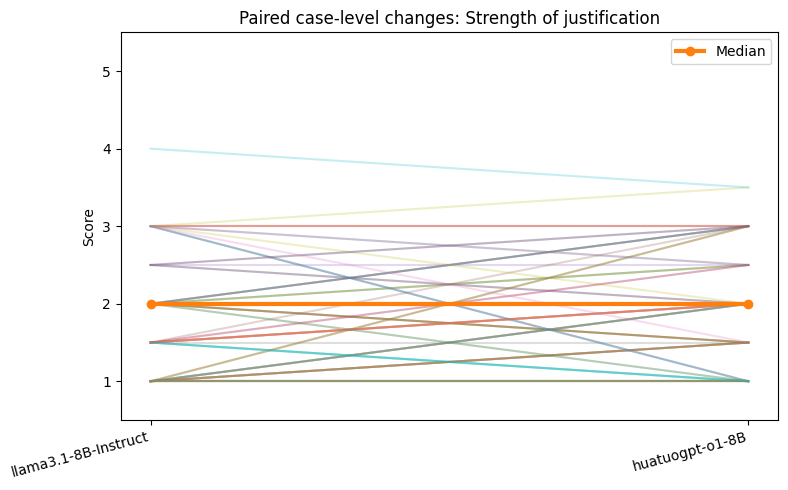

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/paired_lines_Strength_of_justification.png


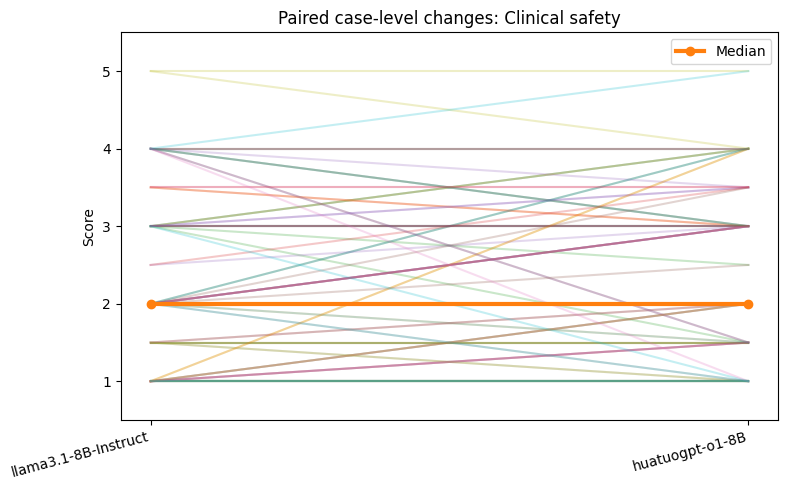

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/paired_lines_Clinical_safety.png


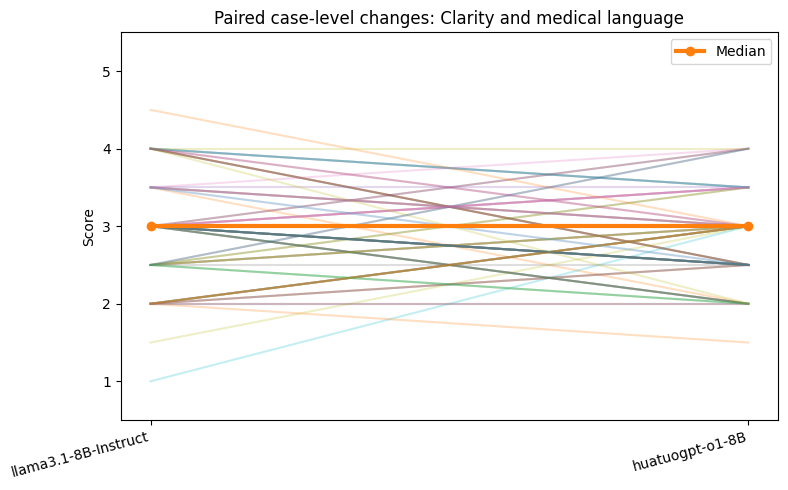

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/paired_lines_Clarity_and_medical_language.png


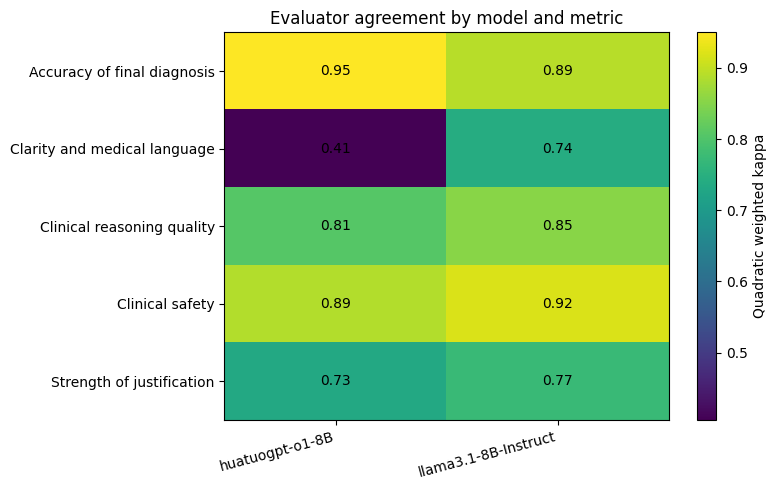

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/agreement_heatmap_weighted_kappa.png


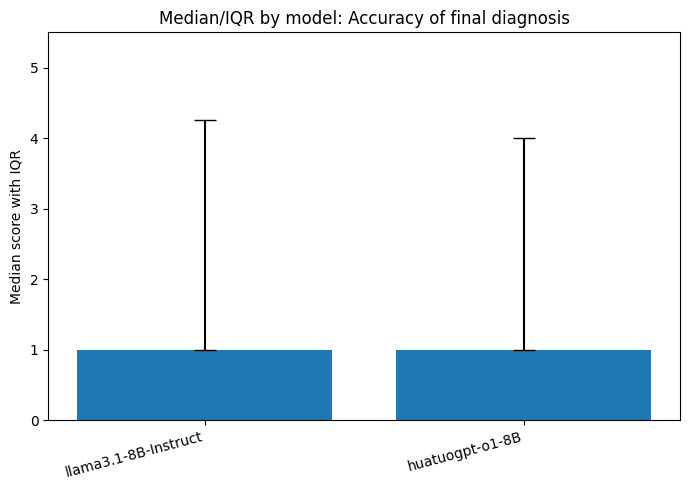

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/median_iqr_Accuracy_of_final_diagnosis.png


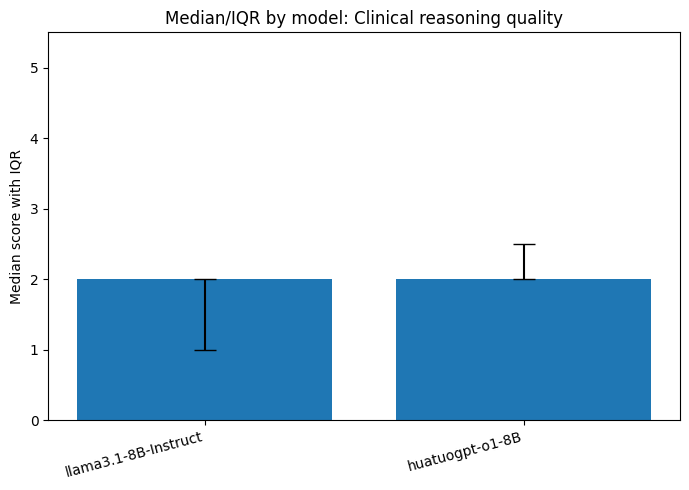

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/median_iqr_Clinical_reasoning_quality.png


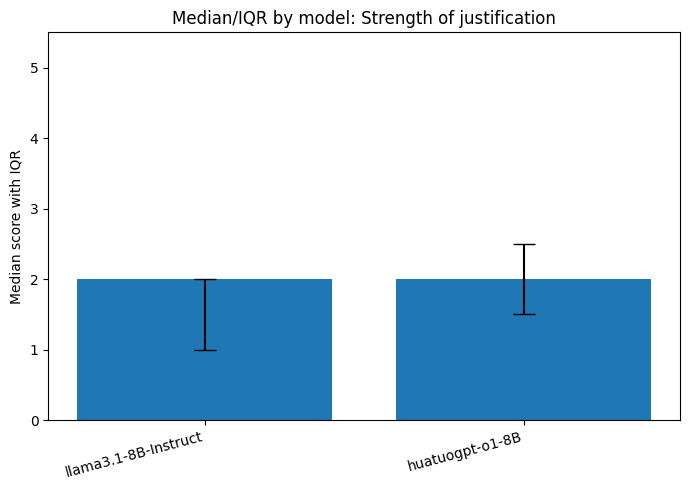

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/median_iqr_Strength_of_justification.png


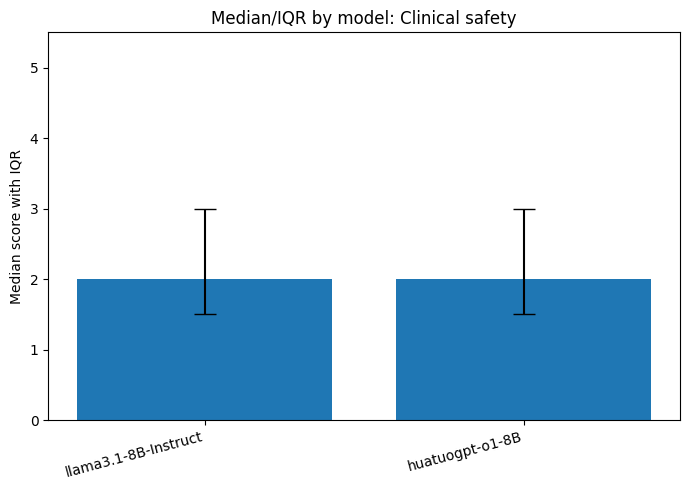

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/median_iqr_Clinical_safety.png


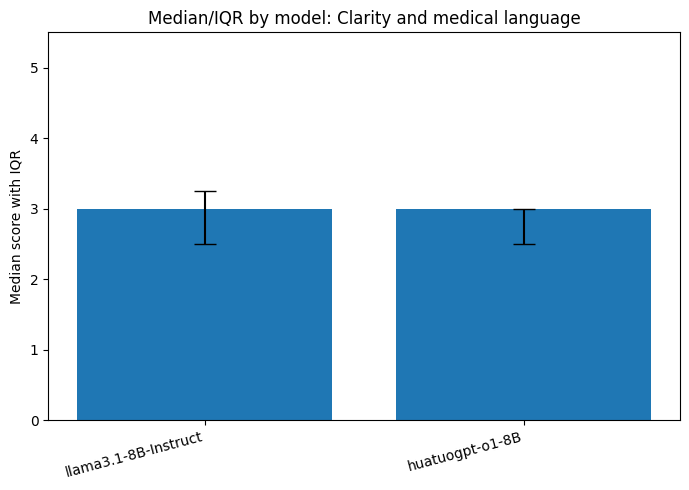

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/median_iqr_Clarity_and_medical_language.png


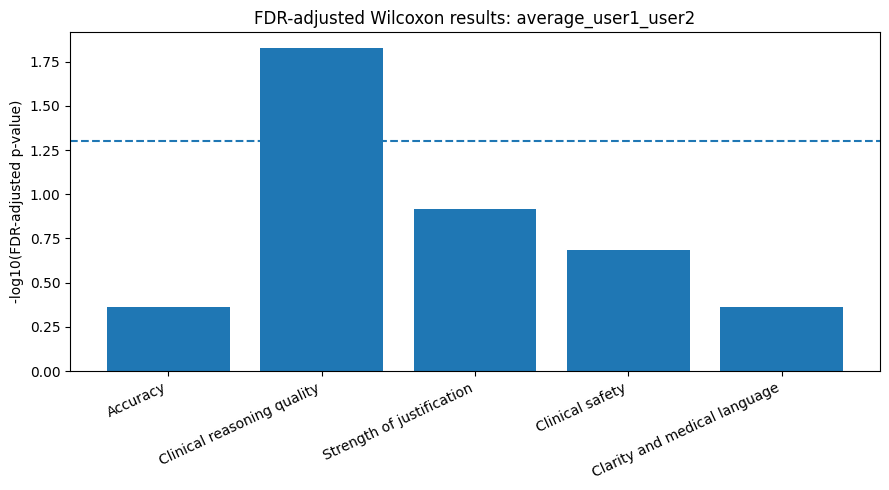

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/fdr_pvalues_average_user1_user2.png


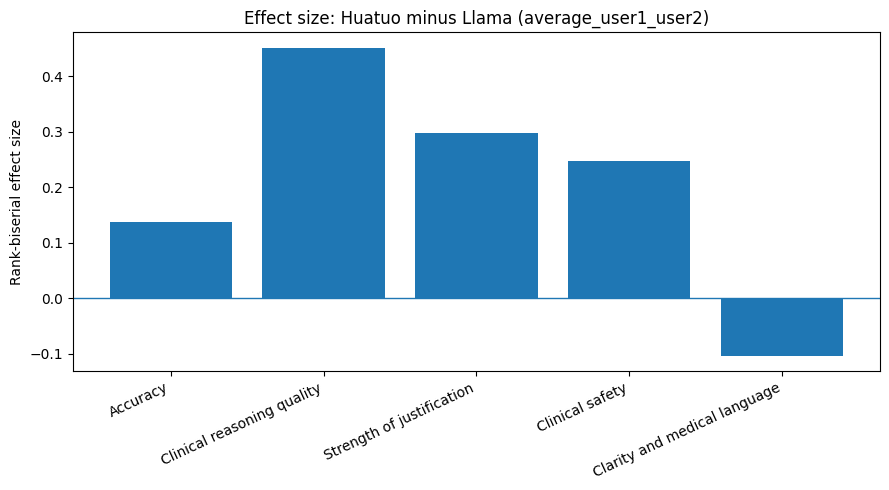

Saved: ../results/OpenEvidence-independent/rating_analysis_plots/effect_sizes_average_user1_user2.png


In [9]:
PLOTS_DIR = DATA_DIR / "rating_analysis_plots"
PLOTS_DIR.mkdir(exist_ok=True)

def safe_name(text):
    return (
        text.replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "_")
    )

def save_current_plot(name):
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {path}")

for metric in METRICS:
    plot_data = [
        analysis_long[(analysis_long["metric"] == metric) & (analysis_long["model"] == MODEL_A)]["score"].dropna().values,
        analysis_long[(analysis_long["metric"] == metric) & (analysis_long["model"] == MODEL_B)]["score"].dropna().values,
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(plot_data, labels=[MODEL_A, MODEL_B], showmeans=True)
    plt.title(f"Boxplot: {metric}")
    plt.ylabel("Score")
    plt.ylim(0.5, 5.5)
    plt.xticks(rotation=15, ha="right")
    save_current_plot(f"boxplot_{safe_name(metric)}.png")

for metric in METRICS:
    plt.figure(figsize=(8, 5))

    for evaluator in sorted(analysis_df["evaluator"].unique()):
        sub = analysis_df[analysis_df["evaluator"] == evaluator]
        wide = sub.pivot_table(index="case_id", columns="model", values=metric, aggfunc="first")
        if MODEL_A in wide.columns and MODEL_B in wide.columns:
            for _, row in wide[[MODEL_A, MODEL_B]].dropna().iterrows():
                plt.plot([0, 1], [row[MODEL_A], row[MODEL_B]], alpha=0.25)

    med_a = analysis_long[(analysis_long["metric"] == metric) & (analysis_long["model"] == MODEL_A)]["score"].median()
    med_b = analysis_long[(analysis_long["metric"] == metric) & (analysis_long["model"] == MODEL_B)]["score"].median()
    plt.plot([0, 1], [med_a, med_b], marker="o", linewidth=3, label="Median")

    plt.xticks([0, 1], [MODEL_A, MODEL_B], rotation=15, ha="right")
    plt.ylabel("Score")
    plt.ylim(0.5, 5.5)
    plt.title(f"Paired case-level changes: {metric}")
    plt.legend()
    save_current_plot(f"paired_lines_{safe_name(metric)}.png")

agreement_matrix = agreement_by_metric.pivot(index="metric", columns="model", values="quadratic_weighted_kappa")

plt.figure(figsize=(8, 5))
plt.imshow(agreement_matrix.values, aspect="auto")
plt.colorbar(label="Quadratic weighted kappa")
plt.xticks(np.arange(len(agreement_matrix.columns)), agreement_matrix.columns, rotation=15, ha="right")
plt.yticks(np.arange(len(agreement_matrix.index)), agreement_matrix.index)

for i in range(agreement_matrix.shape[0]):
    for j in range(agreement_matrix.shape[1]):
        val = agreement_matrix.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.title("Evaluator agreement by model and metric")
save_current_plot("agreement_heatmap_weighted_kappa.png")

summary = (
    analysis_long
    .groupby(["model", "metric"])["score"]
    .agg(median="median", q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75))
    .reset_index()
)

for metric in METRICS:
    sub = summary[summary["metric"] == metric].set_index("model").loc[[MODEL_A, MODEL_B]]
    med = sub["median"].values
    lower = med - sub["q1"].values
    upper = sub["q3"].values - med

    plt.figure(figsize=(7, 5))
    plt.bar([0, 1], med, yerr=[lower, upper], capsize=8)
    plt.xticks([0, 1], [MODEL_A, MODEL_B], rotation=15, ha="right")
    plt.ylabel("Median score with IQR")
    plt.ylim(0, 5.5)
    plt.title(f"Median/IQR by model: {metric}")
    save_current_plot(f"median_iqr_{safe_name(metric)}.png")

plot_results = comparison_results.copy()
plot_results["metric_short"] = plot_results["metric"].str.replace(" of final diagnosis", "", regex=False)

for evaluator in plot_results["evaluator"].unique():
    sub = plot_results[plot_results["evaluator"] == evaluator]

    plt.figure(figsize=(9, 5))
    x = np.arange(len(sub))
    plt.bar(x, -np.log10(sub["p_value_fdr_bh"]))
    plt.axhline(-np.log10(0.05), linestyle="--")
    plt.xticks(x, sub["metric_short"], rotation=25, ha="right")
    plt.ylabel("-log10(FDR-adjusted p-value)")
    plt.title(f"FDR-adjusted Wilcoxon results: {evaluator}")
    save_current_plot(f"fdr_pvalues_{safe_name(str(evaluator))}.png")

    plt.figure(figsize=(9, 5))
    plt.bar(x, sub["rank_biserial_effect_size"])
    plt.axhline(0, linewidth=1)
    plt.xticks(x, sub["metric_short"], rotation=25, ha="right")
    plt.ylabel("Rank-biserial effect size")
    plt.title(f"Effect size: Huatuo minus Llama ({evaluator})")
    save_current_plot(f"effect_sizes_{safe_name(str(evaluator))}.png")

In [10]:
# how do models behave when they succeed vs when they fail?

# LLMs output to MCQ with reasoning can 
# select the right choice but be unsafe
# select incorrect choice but being well-reasoned
# select incorrect choice and be confident / clear

In [11]:
answers = pd.read_csv("./tables/output_llms.csv")
answers = answers[['Unnamed: 0', 'huatuo-o1-prompt1', 'llama31-prompt1', 'truth']]
(answers['llama31-prompt1'] == answers['truth']).sum()

np.int64(34)

In [12]:
# Rename if needed
answers = answers.rename(columns={
    "Unnamed: 0": "case_id",
    "truth": "ground_truth",
    "llama31-prompt1": "llama_answer",
    "huatuo-o1-prompt1": "huatuo_answer"
})

# Normalize answers
for col in ["ground_truth", "llama_answer", "huatuo_answer"]:
    answers[col] = answers[col].astype(str).str.strip().str.upper()

answers["llama_correct"] = answers["llama_answer"] == answers["ground_truth"]
answers["huatuo_correct"] = answers["huatuo_answer"] == answers["ground_truth"]

answers.head()

,case_id,huatuo_answer,llama_answer,ground_truth,llama_correct,huatuo_correct
0,1,B,B,B,True,True
1,2,C,D,A,False,False
2,5,C,B,C,False,True
3,7,E,C,A,False,False
4,8,A,A,E,False,False


In [13]:
print(analysis_long.shape)
analysis_long.head()

(910, 5)


,model,evaluator,case_id,metric,score
0,huatuogpt-o1-8B,average_user1_user2,1,Accuracy of final diagnosis,5.0
1,huatuogpt-o1-8B,average_user1_user2,2,Accuracy of final diagnosis,1.0
2,huatuogpt-o1-8B,average_user1_user2,5,Accuracy of final diagnosis,5.0
3,huatuogpt-o1-8B,average_user1_user2,7,Accuracy of final diagnosis,1.0
4,huatuogpt-o1-8B,average_user1_user2,8,Accuracy of final diagnosis,1.0


In [14]:
correctness_long = pd.concat([
    answers[["case_id", "llama_correct"]].rename(columns={"llama_correct": "correct"}).assign(model="llama3.1-8B-Instruct"),
    answers[["case_id", "huatuo_correct"]].rename(columns={"huatuo_correct": "correct"}).assign(model="huatuogpt-o1-8B")
])

df_scores_correctness = analysis_long.merge(
    correctness_long,
    on=["case_id", "model"],
    how="left"
)

df_scores_correctness["correctness_group"] = np.where(
    df_scores_correctness["correct"],
    "Correct",
    "Incorrect"
)

df_scores_correctness.head()

,model,evaluator,case_id,metric,score,correct,correctness_group
0,huatuogpt-o1-8B,average_user1_user2,1,Accuracy of final diagnosis,5.0,True,Correct
1,huatuogpt-o1-8B,average_user1_user2,2,Accuracy of final diagnosis,1.0,False,Incorrect
2,huatuogpt-o1-8B,average_user1_user2,5,Accuracy of final diagnosis,5.0,True,Correct
3,huatuogpt-o1-8B,average_user1_user2,7,Accuracy of final diagnosis,1.0,False,Incorrect
4,huatuogpt-o1-8B,average_user1_user2,8,Accuracy of final diagnosis,1.0,False,Incorrect


In [15]:
df_scores_correctness.shape # 5 metrics x 2 models x 91 cases

(910, 7)

In [16]:
desc_by_correctness = (
    df_scores_correctness
    .groupby(["model", "correctness_group", "metric"])["score"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        min="min",
        max="max"
    )
    .reset_index()
)

desc_by_correctness

,model,correctness_group,metric,n,mean,std,median,q1,q3,min,max
0,huatuogpt-o1-8B,Correct,Accuracy of final diagnosis,32,4.468750,0.522671,4.50,4.000,5.000,3.5,5.0
1,huatuogpt-o1-8B,Correct,Clarity and medical language,32,2.781250,0.671271,2.75,2.375,3.125,1.5,4.0
2,huatuogpt-o1-8B,Correct,Clinical reasoning quality,32,2.796875,0.536707,3.00,2.500,3.000,2.0,4.0
3,huatuogpt-o1-8B,Correct,Clinical safety,32,3.562500,0.592289,3.50,3.000,4.000,2.5,5.0
4,huatuogpt-o1-8B,Correct,Strength of justification,32,2.625000,0.475191,2.50,2.000,3.000,2.0,3.5
5,huatuogpt-o1-8B,Incorrect,Accuracy of final diagnosis,59,1.194915,0.482602,1.00,1.000,1.000,1.0,3.5
6,huatuogpt-o1-8B,Incorrect,Clarity and medical language,59,2.889831,0.483056,3.00,2.500,3.000,2.0,4.0
7,huatuogpt-o1-8B,Incorrect,Clinical reasoning quality,59,1.889831,0.517519,2.00,2.000,2.000,1.0,3.5
8,huatuogpt-o1-8B,Incorrect,Clinical safety,59,1.745763,0.703274,1.50,1.000,2.000,1.0,4.0
9,huatuogpt-o1-8B,Incorrect,Strength of justification,59,1.593220,0.477733,1.50,1.000,2.000,1.0,3.0


In [17]:
(df_scores_correctness[df_scores_correctness.model=='llama3.1-8B-Instruct'].correctness_group=='Correct').sum()

np.int64(170)

In [19]:
metrics_to_test = [
    "Clinical reasoning quality",
    "Strength of justification",
    "Clinical safety",
    "Clarity and medical language"
]

def rank_biserial_from_wilcoxon(x, y):
    """
    Approximate matched-pairs rank-biserial correlation.
    Positive values mean y > x if difference is y - x.
    """
    diff = y - x
    diff = diff[diff != 0]
    if len(diff) == 0:
        return np.nan

    ranks = pd.Series(abs(diff)).rank()
    w_pos = ranks[diff > 0].sum()
    w_neg = ranks[diff < 0].sum()
    return (w_pos - w_neg) / ranks.sum()

results = []

for correctness_group in ["Correct", "Incorrect"]:
    for metric in metrics_to_test:

        subset = df_scores_correctness[
            (df_scores_correctness["correctness_group"] == correctness_group) &
            (df_scores_correctness["metric"] == metric)
        ]
        print(subset.shape)
        wide = subset.pivot(
            index="case_id",
            columns="model",
            values="score"
        ).dropna()

        if wide.shape[0] < 2:
            continue

        llama = wide["llama3.1-8B-Instruct"]
        huatuo = wide["huatuogpt-o1-8B"]
        print(llama.shape)
        print(huatuo.shape)
        print('--------------')
        diff = huatuo - llama

        try:
            stat, p_value = wilcoxon(huatuo, llama, zero_method="wilcox")
        except ValueError:
            stat, p_value = np.nan, np.nan

        results.append({
            "correctness_group": correctness_group,
            "metric": metric,
            "n_paired_cases": wide.shape[0],
            "llama_median": llama.median(),
            "huatuo_median": huatuo.median(),
            "median_difference_huatuo_minus_llama": diff.median(),
            "wilcoxon_statistic": stat,
            "p_value": p_value,
            "rank_biserial_effect_size": rank_biserial_from_wilcoxon(llama, huatuo)
        })

stratified_results = pd.DataFrame(results)
display(stratified_results)

# FDR correction across all stratified tests
mask = stratified_results["p_value"].notna()

stratified_results.loc[mask, "p_fdr"] = multipletests(
    stratified_results.loc[mask, "p_value"],
    method="fdr_bh"
)[1]

stratified_results

(66, 7)
(26,)
(26,)
--------------
(66, 7)
(26,)
(26,)
--------------
(66, 7)
(26,)
(26,)
--------------
(66, 7)
(26,)
(26,)
--------------
(116, 7)
(51,)
(51,)
--------------
(116, 7)
(51,)
(51,)
--------------
(116, 7)
(51,)
(51,)
--------------
(116, 7)
(51,)
(51,)
--------------


,correctness_group,metric,n_paired_cases,llama_median,huatuo_median,median_difference_huatuo_minus_llama,wilcoxon_statistic,p_value,rank_biserial_effect_size
0,Correct,Clinical reasoning quality,26,3.0,3.0,0.0,50.0,0.563703,0.166667
1,Correct,Strength of justification,26,2.5,2.5,0.0,44.0,0.111168,0.424837
2,Correct,Clinical safety,26,3.5,3.5,0.0,58.0,0.596370,0.147059
3,Correct,Clarity and medical language,26,3.0,2.5,-0.5,33.0,0.003529,-0.714286
4,Incorrect,Clinical reasoning quality,51,1.5,2.0,0.5,46.5,0.000149,0.786207
5,Incorrect,Strength of justification,51,1.5,2.0,0.0,92.0,0.049284,0.433846
6,Incorrect,Clinical safety,51,1.5,2.0,0.0,34.5,0.006937,0.671429
7,Incorrect,Clarity and medical language,51,3.0,3.0,0.0,254.0,0.125996,0.277383


,correctness_group,metric,n_paired_cases,llama_median,huatuo_median,median_difference_huatuo_minus_llama,wilcoxon_statistic,p_value,rank_biserial_effect_size,p_fdr
0,Correct,Clinical reasoning quality,26,3.0,3.0,0.0,50.0,0.563703,0.166667,0.596370
1,Correct,Strength of justification,26,2.5,2.5,0.0,44.0,0.111168,0.424837,0.167995
2,Correct,Clinical safety,26,3.5,3.5,0.0,58.0,0.596370,0.147059,0.596370
3,Correct,Clarity and medical language,26,3.0,2.5,-0.5,33.0,0.003529,-0.714286,0.014114
4,Incorrect,Clinical reasoning quality,51,1.5,2.0,0.5,46.5,0.000149,0.786207,0.001193
5,Incorrect,Strength of justification,51,1.5,2.0,0.0,92.0,0.049284,0.433846,0.098569
6,Incorrect,Clinical safety,51,1.5,2.0,0.0,34.5,0.006937,0.671429,0.018500
7,Incorrect,Clarity and medical language,51,3.0,3.0,0.0,254.0,0.125996,0.277383,0.167995


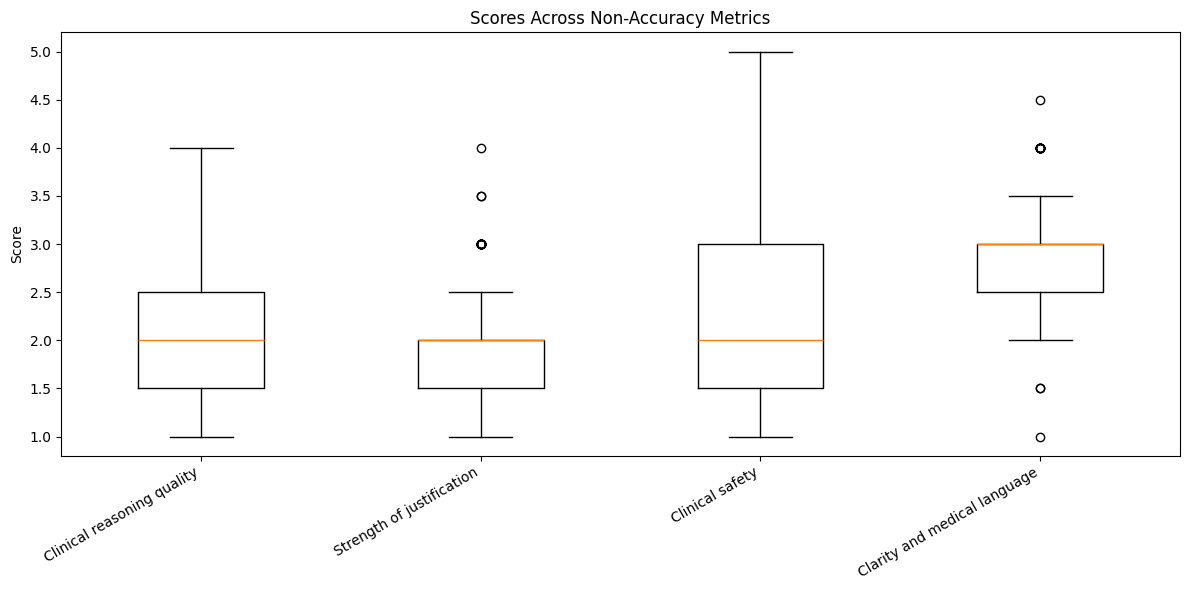

In [20]:
import matplotlib.pyplot as plt

data = df_scores_correctness[
    df_scores_correctness["metric"].isin(metrics_to_test)
]

metrics = metrics_to_test
values = [data[data["metric"] == m]["score"].dropna() for m in metrics]

plt.figure(figsize=(12, 6))
plt.boxplot(values)

plt.xticks(range(1, len(metrics) + 1), metrics, rotation=30, ha="right")
plt.title("Scores Across Non-Accuracy Metrics")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

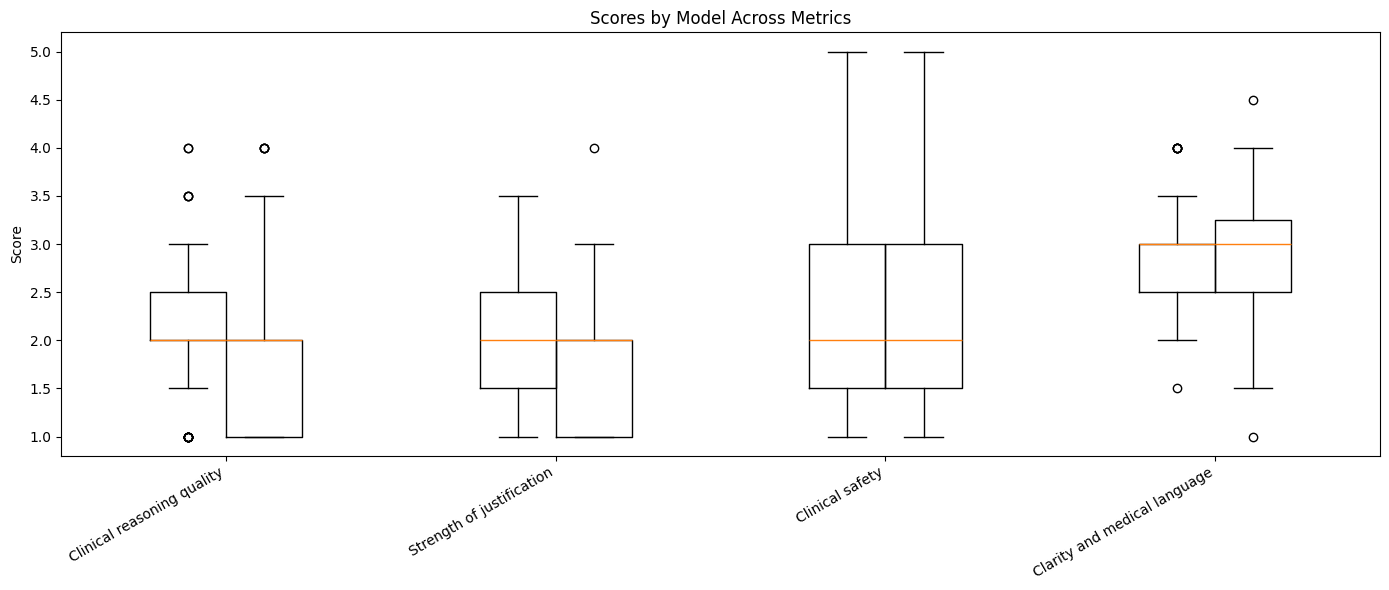

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = df_scores_correctness[
    df_scores_correctness["metric"].isin(metrics_to_test)
]

models = data["model"].unique()
metrics = metrics_to_test

positions = []
box_data = []
labels = []

pos = 1
width = 0.3

for m in metrics:
    for i, model in enumerate(models):
        subset = data[(data["metric"] == m) & (data["model"] == model)]
        box_data.append(subset["score"].dropna())
        positions.append(pos + i * width)
        labels.append(f"{m}\n{model}")
    pos += 1 + width

plt.figure(figsize=(14, 6))
plt.boxplot(box_data, positions=positions, widths=width)

# x-ticks centered per metric
metric_positions = [np.mean(positions[i*len(models):(i+1)*len(models)]) for i in range(len(metrics))]
plt.xticks(metric_positions, metrics, rotation=30, ha="right")

plt.title("Scores by Model Across Metrics")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

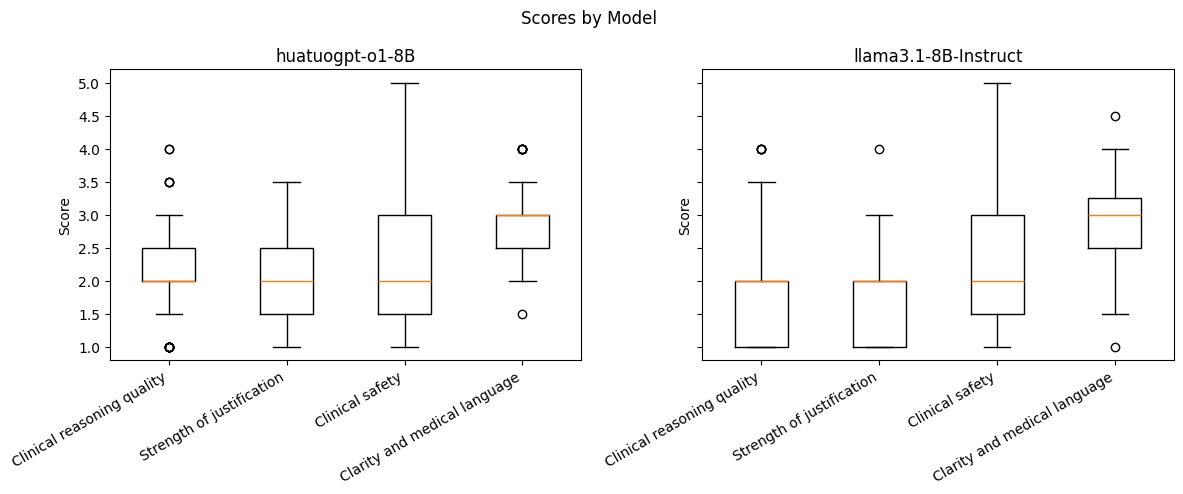

In [22]:
import matplotlib.pyplot as plt

models = df_scores_correctness["model"].unique()
metrics = metrics_to_test

fig, axes = plt.subplots(1, len(models), figsize=(12, 5), sharey=True)

for ax, model in zip(axes, models):
    subset = df_scores_correctness[
        (df_scores_correctness["model"] == model) &
        (df_scores_correctness["metric"].isin(metrics))
    ]

    values = [subset[subset["metric"] == m]["score"].dropna() for m in metrics]

    ax.boxplot(values)
    ax.set_title(model)
    ax.set_xticks(range(1, len(metrics) + 1))
    ax.set_xticklabels(metrics, rotation=30, ha="right")
    ax.set_ylabel("Score")

plt.suptitle("Scores by Model")
plt.tight_layout()
plt.show()

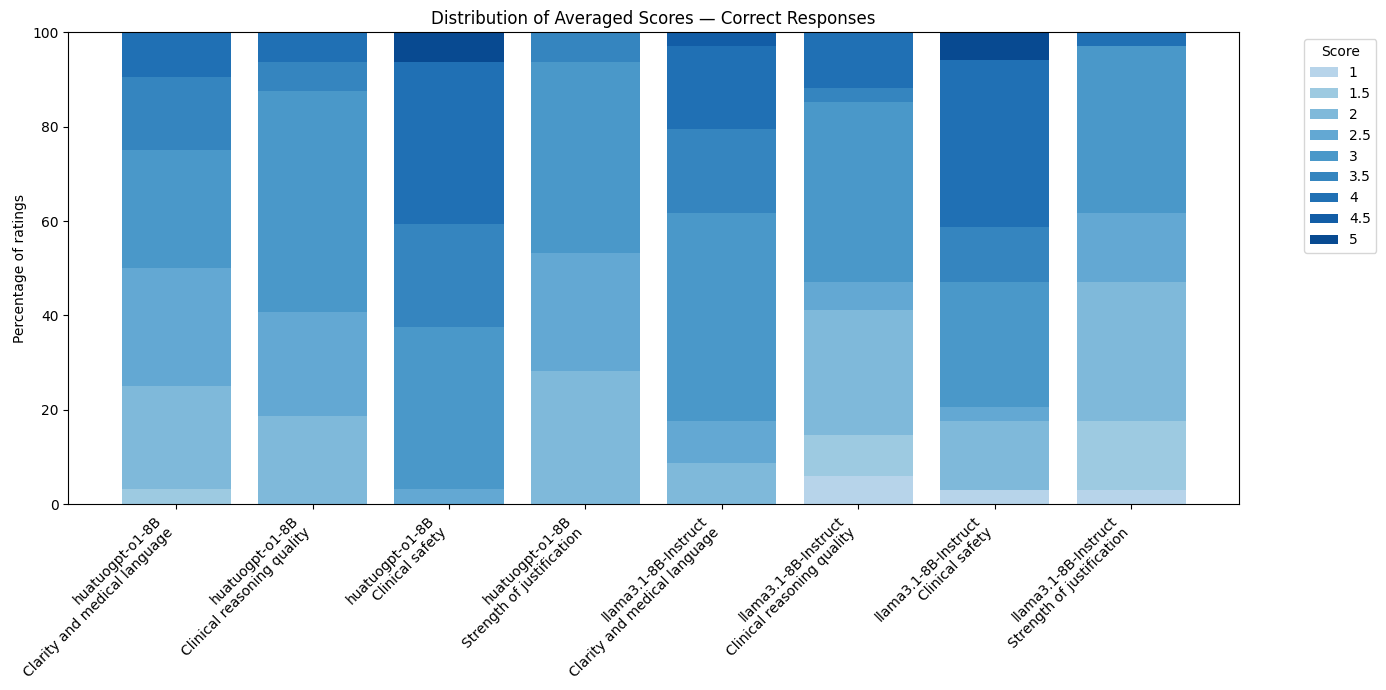

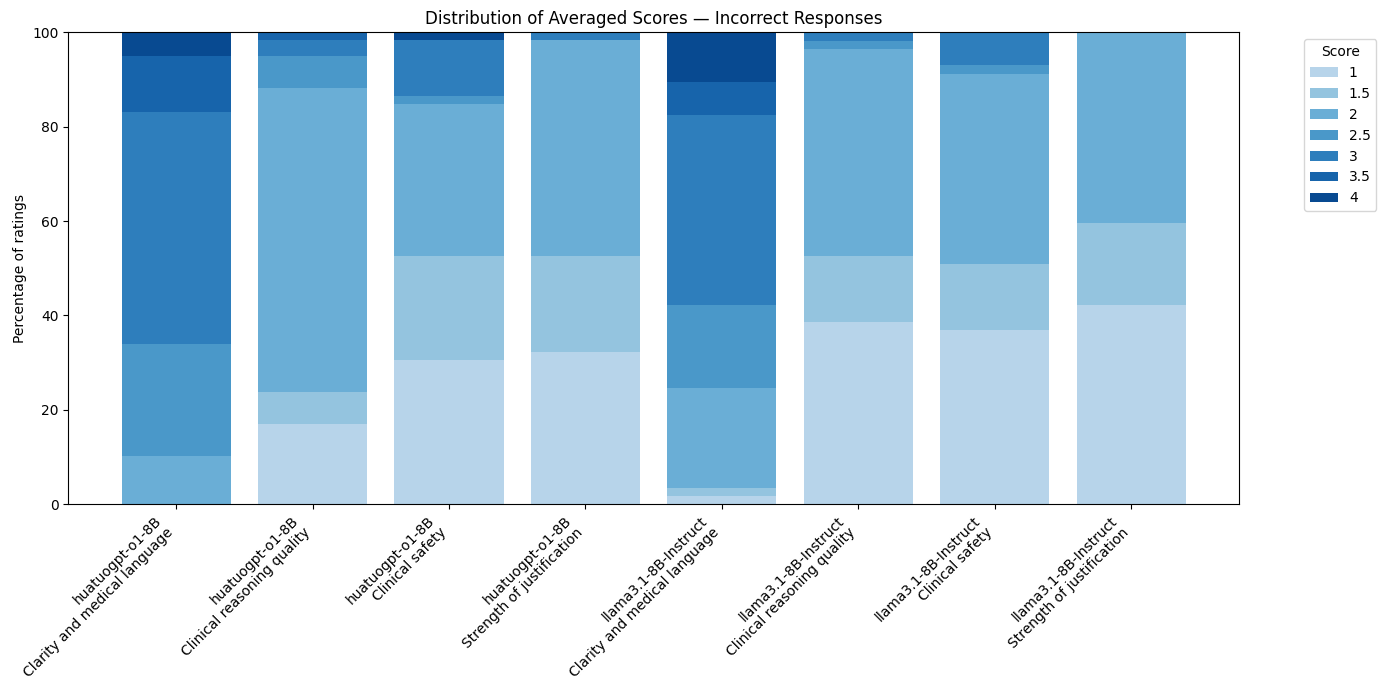

In [24]:
plot_df = df_scores_correctness[
    df_scores_correctness["metric"].isin(metrics_to_test)
].copy()

# use averaged score values honestly, without rounding
plot_df["score_display"] = plot_df["score"]

cmap = plt.cm.Blues

for correctness_group in ["Correct", "Incorrect"]:

    subset = plot_df[plot_df["correctness_group"] == correctness_group]

    likert_values_avg = sorted(subset["score_display"].dropna().unique())

    colors_avg = [
        cmap(0.3 + 0.6 * i / max(len(likert_values_avg) - 1, 1))
        for i in range(len(likert_values_avg))
    ]

    likert_counts_avg = (
        subset
        .groupby(["model", "metric", "score_display"])
        .size()
        .reset_index(name="count")
        .pivot_table(
            index=["model", "metric"],
            columns="score_display",
            values="count",
            fill_value=0
        )
        .reindex(columns=likert_values_avg, fill_value=0)
    )

    likert_percent_avg = likert_counts_avg.div(
        likert_counts_avg.sum(axis=1),
        axis=0
    ) * 100

    labels = [
        f"{model}\n{metric}"
        for model, metric in likert_percent_avg.index
    ]

    x = np.arange(len(labels))
    bottom = np.zeros(len(labels))

    plt.figure(figsize=(14, 7))

    for i, score in enumerate(likert_values_avg):
        values = likert_percent_avg[score].values
        plt.bar(
            x,
            values,
            bottom=bottom,
            color=colors_avg[i],
            label=f"{score:g}"
        )
        bottom += values

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Percentage of ratings")
    plt.title(f"Distribution of Averaged Scores — {correctness_group} Responses")
    plt.ylim(0, 100)
    plt.legend(title="Score", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [28]:
analysis_df[(analysis_df['model'] == 'huatuogpt-o1-8B') & analysis_df['case_id'].isin([27, 36, 37, 57, 60, 71, 75, 94])]

,model,case_id,Accuracy of final diagnosis,Clinical reasoning quality,Strength of justification,Clinical safety,Clarity and medical language,evaluator
23,huatuogpt-o1-8B,27,1.5,2.0,2.0,2.0,4.0,average_user1_user2
30,huatuogpt-o1-8B,36,1.0,2.0,1.5,1.0,3.0,average_user1_user2
31,huatuogpt-o1-8B,37,1.5,2.5,2.0,2.0,3.0,average_user1_user2
50,huatuogpt-o1-8B,57,1.0,2.5,2.0,3.0,2.5,average_user1_user2
53,huatuogpt-o1-8B,60,3.0,3.0,2.0,3.0,3.0,average_user1_user2
63,huatuogpt-o1-8B,71,2.0,2.0,2.0,3.0,3.0,average_user1_user2
67,huatuogpt-o1-8B,75,1.0,2.0,1.0,2.0,2.5,average_user1_user2
85,huatuogpt-o1-8B,94,2.0,2.0,2.0,3.0,2.5,average_user1_user2
